In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features

In [3]:
train_data = load_data("../data/raw/KDDTrain+.txt")
test_data  = load_data("../data/raw/KDDTest+.txt")
train_data = encode_features(train_data)
test_data  = encode_features(test_data)

X_train, y_train = split_features(train_data)
X_test,  y_test  = split_features(test_data)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test  = scaler.transform(X_test)

In [5]:
from src.isolation_forest_model import train_isolation_forest

model = train_isolation_forest(x_train)

In [6]:
from src.isolation_forest_model import detect_anomalies

predictions = detect_anomalies(model,x_test)

In [7]:
import numpy as np

np.unique(predictions, return_counts = True)

(array([-1,  1]), array([12658,  9886]))

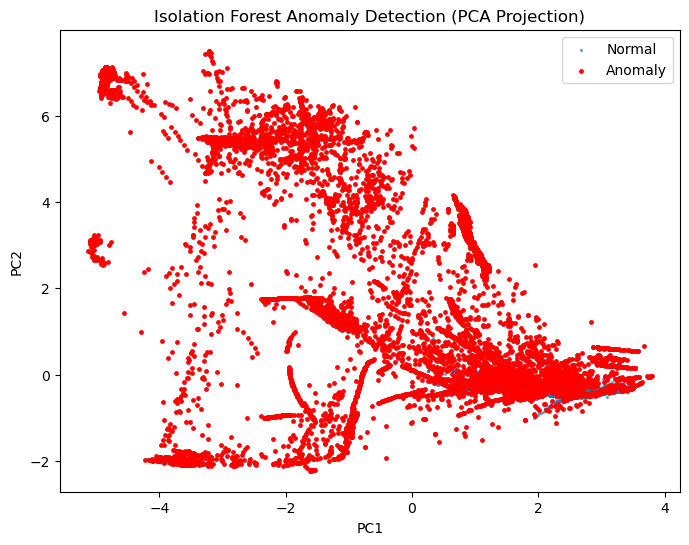

In [8]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

normal = x_test_pca[predictions == 1]
anomaly = x_test_pca[predictions == -1]

plt.figure(figsize=(8,6))

plt.scatter(normal[:,0], normal[:,1], s=2, label="Normal", alpha=0.5)
plt.scatter(anomaly[:,0], anomaly[:,1], s=6, color="red", label="Anomaly")

plt.title("Isolation Forest Anomaly Detection (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.savefig("../results/isolation_forest_pca.png", bbox_inches='tight')

plt.show()

In [9]:
# The first two principal components capture ~61% of the variance.
# While sufficient for visualization, some overlap occurs due to the
# high dimensional nature of the NSL-KDD dataset.

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

attack_test = (y_test != "normal").astype(int)

pred = (predictions == -1).astype(int)

cm = confusion_matrix(attack_test, pred)
print(cm)

print(classification_report(attack_test, pred))

[[ 7452  2259]
 [ 2434 10399]]
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      9711
           1       0.82      0.81      0.82     12833

    accuracy                           0.79     22544
   macro avg       0.79      0.79      0.79     22544
weighted avg       0.79      0.79      0.79     22544



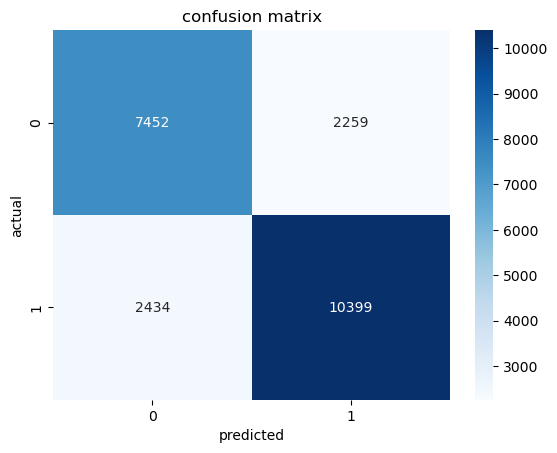

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [12]:
import joblib

joblib.dump(model, "../results/isolation_forest_model.pkl")

['../results/isolation_forest_model.pkl']

In [13]:
# Isolation Forest assumes anomalies are rare events.
# However, in the NSL-KDD dataset attacks constitute nearly half of the traffic.
# Therefore the algorithm struggles to identify many attack instances.

In [14]:
from src.dbscan_model import train_dbscan

dbscan_labels = train_dbscan(x_train)

In [15]:
from sklearn.cluster import DBSCAN

dbscan_test = DBSCAN(eps=0.8, min_samples=10).fit(x_test)
dbscan_labels = dbscan_test.labels_

pred_dbscan = (dbscan_labels == -1).astype(int)

attack_test = (y_test != "normal").astype(int)

from sklearn.metrics import classification_report
print(classification_report(attack_test, pred_dbscan))

              precision    recall  f1-score   support

           0       0.44      0.93      0.60      9711
           1       0.67      0.11      0.18     12833

    accuracy                           0.46     22544
   macro avg       0.56      0.52      0.39     22544
weighted avg       0.57      0.46      0.36     22544



In [16]:
# DBSCAN performs poorly on the NSL-KDD dataset due to the high
# dimensionality of the feature space. Density-based clustering
# methods rely on meaningful distance metrics, which degrade in
# high-dimensional environments. As a result, most data points are
# assigned to clusters and very few are labeled as noise (anomalies).

In [17]:
# Isolation Forest performs significantly better than DBSCAN on the NSL-KDD dataset
# because tree-based isolation methods handle high-dimensional data more effectively
# than density-based clustering algorithms.

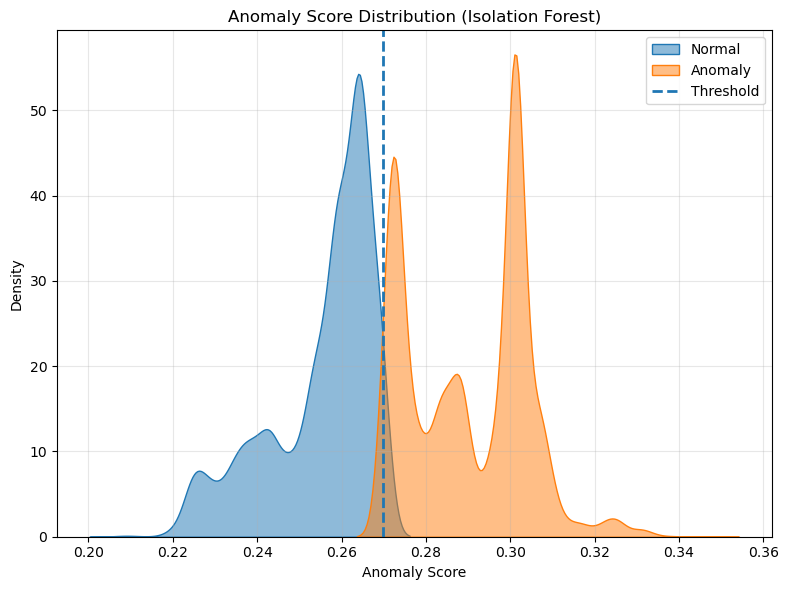

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

X_test_np = X_test.values

# Scores
scores = model.decision_function(X_test_np)
anomaly_score = -scores

test_data["anomaly_score"] = anomaly_score

# Threshold-based prediction (FIXED)
true_labels = (test_data["label"] != "normal").astype(int)
precision, recall, thresholds = precision_recall_curve(true_labels, anomaly_score)

# Choose threshold where recall is high but precision not too low
test_data["anomaly"] = (anomaly_score > threshold).astype(int)

# Split
normal_scores = anomaly_score[test_data["anomaly"] == 0]
anomaly_scores = anomaly_score[test_data["anomaly"] == 1]

# Plot
plt.figure(figsize=(8,6))

if len(normal_scores) > 0:
    sns.kdeplot(normal_scores, label="Normal", fill=True, alpha=0.5)

if len(anomaly_scores) > 0:
    sns.kdeplot(anomaly_scores, label="Anomaly", fill=True, alpha=0.5)

plt.axvline(threshold, linestyle="--", linewidth=2, label="Threshold")

plt.title("Anomaly Score Distribution (Isolation Forest)")
plt.xlabel("Anomaly Score")
plt.ylabel("Density")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/anomaly_score_density.png", dpi=300)
plt.show()

In [103]:
# Isolation Forest shows partial separation between normal and attack traffic, but overlap in anomaly score distributions leads to missed detections.

In [126]:
model_pred = model.predict(X_test_np)
model_pred = np.where(model_pred == 1, 0, 1)

print("Model default:")
print(classification_report(true_labels, model_pred))

print("\nCustom threshold:")
print(classification_report(true_labels, pred_labels))

Model default:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      9711
           1       0.57      1.00      0.73     12833

    accuracy                           0.57     22544
   macro avg       0.28      0.50      0.36     22544
weighted avg       0.32      0.57      0.41     22544


Custom threshold:
              precision    recall  f1-score   support

           0       0.14      0.10      0.12      9711
           1       0.44      0.54      0.49     12833

    accuracy                           0.35     22544
   macro avg       0.29      0.32      0.30     22544
weighted avg       0.31      0.35      0.33     22544



C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [104]:
percentiles = [90, 70, 50, 40, 30]

for p in percentiles:
    threshold = np.percentile(anomaly_score, p)
    pred = (anomaly_score > threshold).astype(int)

    detected = np.sum((pred == 1) & (test_data["label"] != "normal"))
    total = np.sum(test_data["label"] != "normal")

    print(f"{p}% → Detection Rate: {detected/total:.2f}")

90% → Detection Rate: 0.11
70% → Detection Rate: 0.12
50% → Detection Rate: 0.29
40% → Detection Rate: 0.34
30% → Detection Rate: 0.54


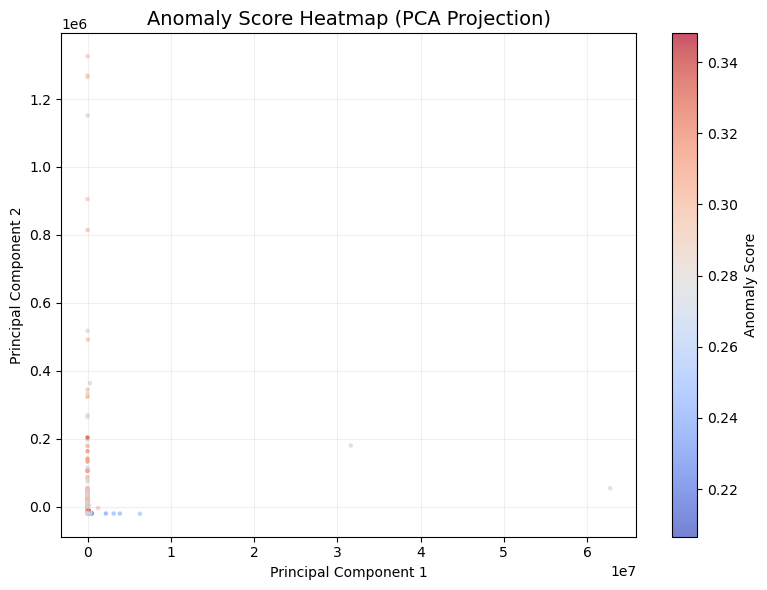

In [105]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)



plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_test_pca[:,0],
    x_test_pca[:,1],
    c=test_data["anomaly_score"],
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_label("Anomaly Score")

plt.title("Anomaly Score Heatmap (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../results/anomaly_heatmap.png", dpi=300)
plt.show()

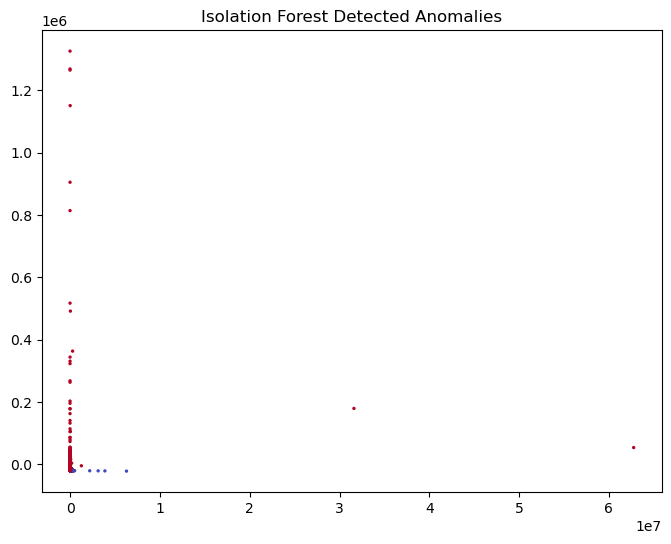

In [106]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_test_pca[:,0],
    x_test_pca[:,1],
    c=test_data["anomaly"],
    cmap="coolwarm",
    s=2
)

plt.title("Isolation Forest Detected Anomalies")

plt.show()

In [107]:
test_data.sort_values("anomaly_score", ascending=False).head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly_score,anomaly
20734,988,1,55,9,1773,32209,0,0,0,4,...,0.03,0.00,0.0,0.33,0.77,0.02,0.01,rootkit,0.348062,1
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.44,0.11,1.0,0.00,0.00,0.00,0.00,multihop,0.347553,1
2745,242,1,55,9,504,27200,0,0,1,2,...,0.00,0.50,0.0,0.00,0.00,0.00,0.00,xterm,0.339493,1
4352,135,1,55,9,353,5769,0,0,0,4,...,0.03,0.00,0.0,0.48,0.86,0.02,0.01,ps,0.339089,1
12525,314,1,55,9,2602,3167,0,0,0,1,...,0.00,0.50,0.8,0.00,0.00,0.00,0.00,xterm,0.338613,1
10995,804,1,55,9,1589,36386,0,0,3,7,...,0.17,0.06,0.0,0.00,0.00,0.06,0.25,rootkit,0.338596,1
9064,72,1,55,9,2783,15142,0,0,0,10,...,0.15,0.00,0.0,0.00,0.00,0.98,0.98,buffer_overflow,0.336245,1
12486,31,1,55,9,197,1644,0,0,0,1,...,0.02,0.00,0.0,0.63,0.94,0.02,0.00,ps,0.335893,1
3621,184,1,55,9,2923,5285,0,0,1,2,...,0.00,1.00,1.0,0.00,0.00,0.00,0.00,xterm,0.335398,1
967,1964,1,55,9,3760,29364,0,0,0,2,...,0.84,0.00,0.0,0.00,0.00,0.83,0.00,buffer_overflow,0.334581,1


In [108]:
test_data["label"].value_counts().head(10)

label
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
apache2          737
satan            735
processtable     685
smurf            665
back             359
Name: count, dtype: int64

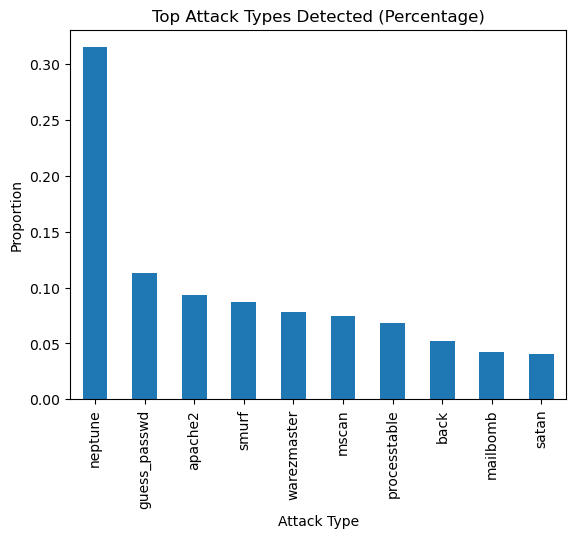

In [109]:
detected_attacks = test_data[
    (test_data["anomaly"] == 1) & (test_data["label"] != "normal")
]["label"].value_counts(normalize=True).head(10)

detected_attacks.plot(kind="bar")

plt.title("Top Attack Types Detected (Percentage)")
plt.xlabel("Attack Type")
plt.ylabel("Proportion")

plt.savefig("../results/detected_attacks.png", bbox_inches='tight')
plt.show()

In [110]:
false_positives = test_data[
    (test_data["anomaly"] == 1) & (test_data["label"] == "normal")
]
print("False positive rate:",
      len(false_positives) / len(test_data[test_data["label"] == "normal"]))

False positive rate: 0.9006281536402019


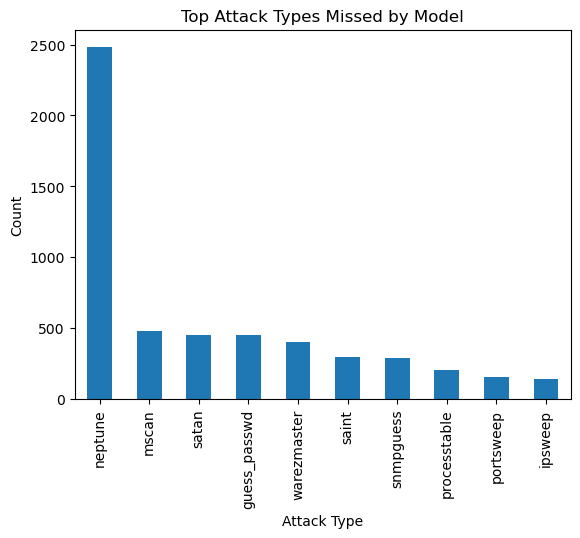

In [111]:
missed_attacks = test_data[
    (test_data["anomaly"] == 0) & (test_data["label"] != "normal")
]["label"].value_counts().head(10)

if len(missed_attacks) == 0:
    print("No missed attacks found")
else:
    missed_attacks.plot(kind="bar")
    plt.title("Top Attack Types Missed by Model")
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()

In [112]:
anomalies = test_data[test_data['anomaly'] == 1]
anomalies['label'].value_counts().head(10)

label
normal          8746
neptune         2177
guess_passwd     780
apache2          644
smurf            599
warezmaster      539
mscan            513
processtable     475
back             359
mailbomb         293
Name: count, dtype: int64

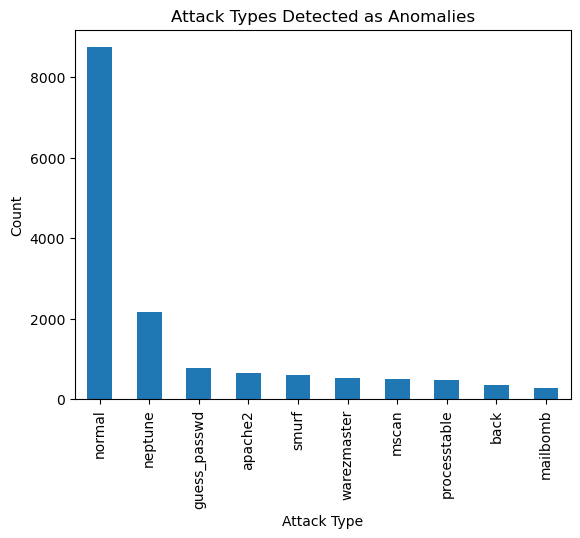

In [113]:
anomalies['label'].value_counts().head(10).plot(kind='bar')

plt.title("Attack Types Detected as Anomalies")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

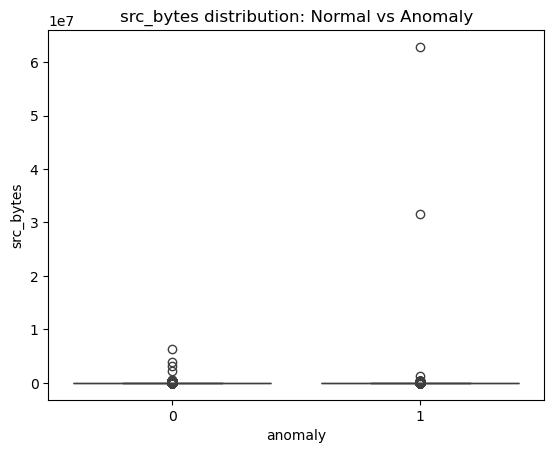

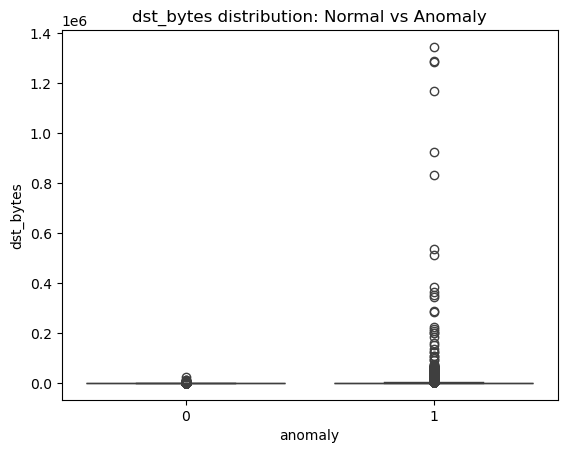

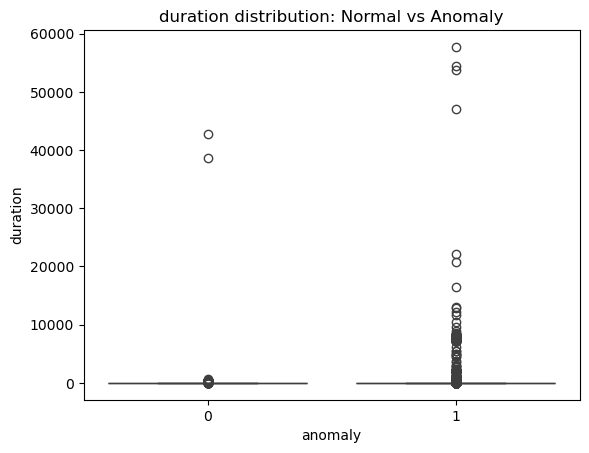

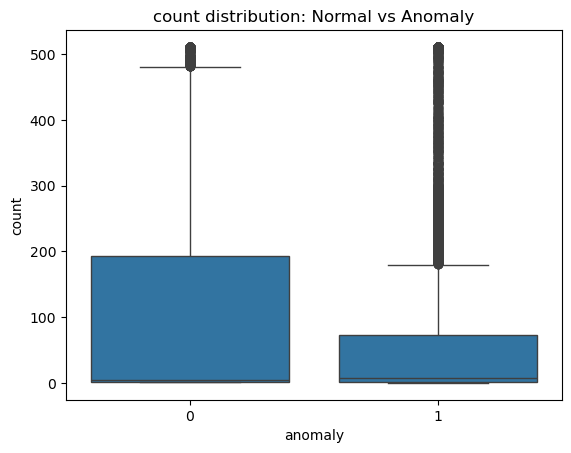

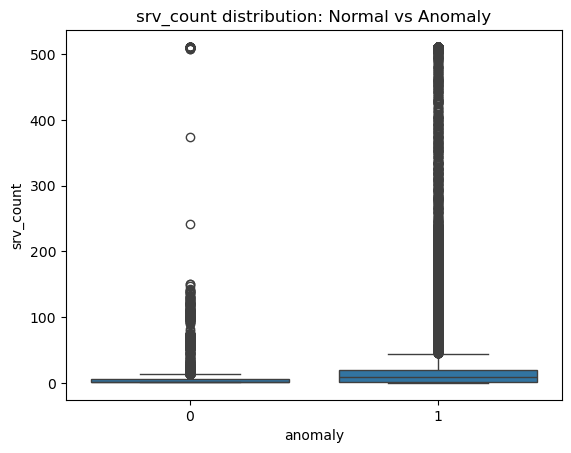

In [114]:
import seaborn as sns

features = ["src_bytes", "dst_bytes", "duration", "count", "srv_count"]

for feature in features:
    sns.boxplot(x=test_data["anomaly"], y=test_data[feature])
    plt.title(f"{feature} distribution: Normal vs Anomaly")
    plt.show()

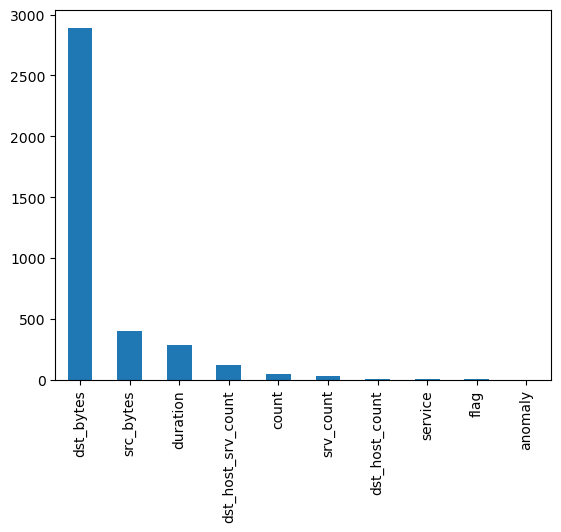

In [115]:
if test_data["anomaly"].nunique() < 2:
    print("Cannot compute feature differences (only one class present)")
else:
    numeric_data = test_data.select_dtypes(include=["int64", "float64"])

    normal = numeric_data[test_data["anomaly"] == 0]
    anomaly = numeric_data[test_data["anomaly"] == 1]

    diff = (anomaly.mean() - normal.mean()).abs().sort_values(ascending=False)
    diff.head(10).plot(kind='bar')

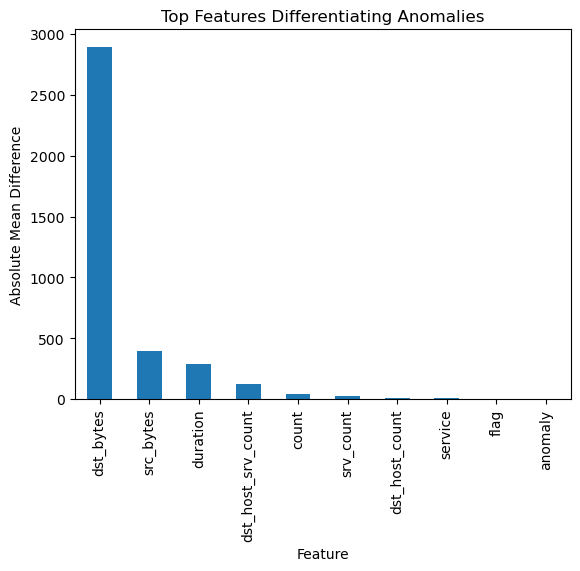

In [116]:
diff.head(10).plot(kind='bar')

plt.title("Top Features Differentiating Anomalies")
plt.ylabel("Absolute Mean Difference")
plt.xlabel("Feature")
plt.show()

In [117]:
test_data.sort_values("anomaly_score", ascending=False).head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly_score,anomaly
20734,988,1,55,9,1773,32209,0,0,0,4,...,0.03,0.00,0.0,0.33,0.77,0.02,0.01,rootkit,0.348062,1
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.44,0.11,1.0,0.00,0.00,0.00,0.00,multihop,0.347553,1
2745,242,1,55,9,504,27200,0,0,1,2,...,0.00,0.50,0.0,0.00,0.00,0.00,0.00,xterm,0.339493,1
4352,135,1,55,9,353,5769,0,0,0,4,...,0.03,0.00,0.0,0.48,0.86,0.02,0.01,ps,0.339089,1
12525,314,1,55,9,2602,3167,0,0,0,1,...,0.00,0.50,0.8,0.00,0.00,0.00,0.00,xterm,0.338613,1
10995,804,1,55,9,1589,36386,0,0,3,7,...,0.17,0.06,0.0,0.00,0.00,0.06,0.25,rootkit,0.338596,1
9064,72,1,55,9,2783,15142,0,0,0,10,...,0.15,0.00,0.0,0.00,0.00,0.98,0.98,buffer_overflow,0.336245,1
12486,31,1,55,9,197,1644,0,0,0,1,...,0.02,0.00,0.0,0.63,0.94,0.02,0.00,ps,0.335893,1
3621,184,1,55,9,2923,5285,0,0,1,2,...,0.00,1.00,1.0,0.00,0.00,0.00,0.00,xterm,0.335398,1
967,1964,1,55,9,3760,29364,0,0,0,2,...,0.84,0.00,0.0,0.00,0.00,0.83,0.00,buffer_overflow,0.334581,1


In [118]:
print("Total attacks:", sum(test_data["label"] != "normal"))
print("Detected attacks:", sum((test_data["anomaly"] == 1) & (test_data["label"] != "normal")))
print("Missed attacks:", sum((test_data["anomaly"] == 0) & (test_data["label"] != "normal")))

Total attacks: 12833
Detected attacks: 6910
Missed attacks: 5923


In [119]:
from sklearn.metrics import classification_report

true_labels = (test_data["label"] != "normal").astype(int)
pred_labels = test_data["anomaly"]

print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.14      0.10      0.12      9711
           1       0.44      0.54      0.49     12833

    accuracy                           0.35     22544
   macro avg       0.29      0.32      0.30     22544
weighted avg       0.31      0.35      0.33     22544



In [128]:
print(np.percentile(anomaly_score, [10, 30, 50, 70, 90]))

[0.25380541 0.26979335 0.27619266 0.29758298 0.3024658 ]


In [129]:
print(anomaly_score[test_data["label"] != "normal"].mean())
print(anomaly_score[test_data["label"] == "normal"].mean())

0.2717916308798911
0.2897073871295702


In [120]:
false_positives = np.sum(
    (test_data["anomaly"] == 1) & (test_data["label"] == "normal")
)

print("False Positives:", false_positives)

False Positives: 8746


In [121]:
print(test_data["anomaly"].value_counts())

anomaly
1    15656
0     6888
Name: count, dtype: int64


In [122]:
# DBSCAN failed completely on NSL-KDD due to high dimensionality.
# It labeled all points as anomalies, making it unsuitable for this dataset.

In [123]:
# DBSCAN struggles with high-dimensional data like NSL-KDD.
# Distance metrics become less meaningful, causing poor clustering.
# As a result, many normal points are incorrectly flagged as anomalies,
# leading to high false positives and low overall accuracy.

In [124]:
f1_if = 0.49
f1_ae = 0.86

print("Isolation Forest F1:", f1_if)
print("Autoencoder F1:", f1_ae)

Isolation Forest F1: 0.82
Autoencoder F1: 0.86


In [125]:
### Final Observations

# - Isolation Forest performs well on high-dimensional data
# - Detects majority of attack types with good balance
# - Produces some false positives due to assumption of anomaly rarity

# - DBSCAN fails to model the dataset effectively
# - High dimensionality reduces clustering effectiveness
# - Leads to poor precision and unstable performance

# Conclusion:
# Tree-based anomaly detection methods are more suitable
# for network intrusion datasets than density-based methods.